In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from ptlpinns.models import train_PDE, model, transfer_wave
from ptlpinns.odes import numerical
from ptlpinns.perturbation import LKV
import torch
from scipy.integrate import solve_ivp
import numpy as np

/home/jovyan/PTL-PINNs/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Transfer parameters

In [2]:
L, T = 2, 5
x_span, t_span = (0, L), (0, T) 

Nx, Nt = 50, 50
x, t, grid = train_PDE.generate_interior_tensor(IG=(Nx, Nt), x_span=(0, L), t_span=(0, T), require_grad=False)

X_grid = np.linspace(0, L, Nx)
t_eval = np.linspace(0, T, Nt)
mesh_x, mesh_t = np.meshgrid(X_grid, t_eval)

In [3]:
c, D = 1, 1
epsilon = 0.5
epsilons = [epsilon]
p = 5

def ic_sin(input):
    x = input[:, 0].unsqueeze(1)
    return (torch.sin(torch.pi * x / L))

def constant_function(constant):
    '''return a function input  ((x,t)in torch) -> constant, can be given as function.

    for example constant_function(0) will return a function that returns 0 for any input.
    '''
    def forcing_function_constant(input):
        return constant*torch.ones_like(input[:, 0].unsqueeze(1))
    return forcing_function_constant

icD = ic_sin
icN = constant_function(0)
bcs = [constant_function(0), constant_function(0)] 
Polynomial = [[1,3]]
forcing=constant_function(0)

In [4]:
def solution_wave(epsilons, c, polynomial, x_span, t_span, Nx, Nt, u0, v0, forcing, bcs, method="RK45", atol=1e-10, rtol=1e-10):
 
    Numerical_solutions = np.zeros((len(epsilons), Nx, Nt))
    
    for i in range(len(epsilons)):
        x = np.linspace(x_span[0], x_span[1], Nx)
        dx = x[1] - x[0]
        t = np.linspace(t_span[0], t_span[1], Nt)
        
        # Convert second-order PDE to system of first-order ODEs
        def rhs(t, y):
            """
            y = [u, v] where v = u_t
            y[:Nx] = u (displacement)
            y[Nx:] = v (velocity)
            """
            u = y[:Nx]
            v = y[Nx:]
            
            # Initialize second derivative
            u_xx = np.zeros_like(u)
            
            # Apply boundary conditions to u
            u[0] = bcs[i][0](t) if callable(bcs[i][0]) else bcs[i][0]
            u[-1] = bcs[i][1](t) if callable(bcs[i][1]) else bcs[i][1]
            
            # Compute second spatial derivative (central difference)
            u_xx[1:-1] = (u[2:] - 2*u[1:-1] + u[:-2]) / (dx**2)
            
            # Apply boundary conditions to second derivative if needed
            # For Dirichlet BCs, u_xx at boundaries can be computed from neighbors
            if callable(bcs[i][0]):
                # Left boundary: use one-sided difference
                u_xx[0] = (u[2] - 2*u[1] + u[0]) / (dx**2)
            else:
                u_xx[0] = 0
                
            if callable(bcs[i][1]):
                # Right boundary: use one-sided difference  
                u_xx[-1] = (u[-1] - 2*u[-2] + u[-3]) / (dx**2)
            else:
                u_xx[-1] = 0
            
            # System of equations:
            du_dt = v  # u_t = v
            dv_dt = c**2 * u_xx - epsilons[i] * polynomial[i](u) + forcing[i](x, t)  # v_t = c^2 u_xx - ε N(u) + f
            
            return np.concatenate([du_dt, dv_dt])
        
        # Initial conditions
        u_initial = u0[i](x)
        v_initial = v0[i](x)
        y0 = np.concatenate([u_initial, v_initial])
        
        # Solve the system
        sol = solve_ivp(rhs, t_span=t_span, y0=y0, t_eval=t, method=method, rtol=rtol, atol=atol)
        
        # Extract displacement solution (first Nx components)
        Numerical_solutions[i, :, :] = sol.y[:Nx, :]
    
    return Numerical_solutions

def polynomial_nonlinearity(u):
    return u**3

polynomial = [polynomial_nonlinearity]

def initial_displacement(x):
    return (np.sin(np.pi * x / 2))

def initial_velocity(x):
    return np.zeros_like(x)

def forcing_func(x, t):
    return np.zeros_like(x) 

def left_bc(t):
    return 0.0

def right_bc(t):
    return 0.0

u0 = [initial_displacement]
v0 = [initial_velocity]  

# Solve
numerical_solution = solution_wave(epsilons, c, polynomial, x_span, t_span, Nx, Nt, 
                        u0, v0, [lambda x, t: np.zeros_like(x)], [(left_bc, right_bc)])[0]

### Load the model

In [5]:
name = "model_Wave_linear.pth"
path = "/home/jovyan/PTL-PINNs/ptlpinns/models/train/Wave_linear"
pinn = model.Multihead_model_PDE(k=9, bias=True)
pinn.load_state_dict(torch.load(f'{path}/{name}'))

bias = True
w_pde, w_bc, w_ic = 1, 10, 10

training_log = {
    'name': name,
    'bias': bias,
    'k' : 9,
    'domain_info':{
        'L': L,
        'T': T,},
    'Nx' : Nx,
    'Nt' : Nt,
    'w_pde': w_pde,
    'w_bc': w_bc,
    'w_ic': w_ic,}

### Validate Multi-head

In [6]:
H_dict = transfer_wave.compute_H_dict(model = pinn,IG = (Nx,Nt),Nic = Nx,Nbc = Nt, bias = False,x_span= x_span,t_span= t_span,log = training_log)

Differentiating H w.r.t. x now...


Finished computing H2x.
Differentiating H w.r.t. t now...


Finished computing H2t
Differentiating H_ic w.r.t. t now...
Finished computing Ht_bc


In [7]:
_, _, _ = transfer_wave.compute_M(H_dict= H_dict,w_pde=1,w_ic=10,w_bc=10)
_, H_dict = transfer_wave.compute_R_ic(H_dict,ic_functionD=icD, ic_functionN=icN, w_ic=10,log=training_log)
_,_,_,H_dict = transfer_wave.compute_R_bcs(H_dict,boundary_functions=bcs ,w_bc=10, log=training_log)

In [8]:
input = torch.cat((x.unsqueeze(1), t.unsqueeze(1)), dim=1) 
NN_TL_pertubation_solution, _ = transfer_wave.compute_perturbation_solution_polynomial_complete(p, epsilon,H_dict=H_dict, input=input,training_log=training_log, forcing=forcing,Polynomial=Polynomial,boundary_functions=bcs,ic_functionD=icD,ic_functionN=icN)
NN_TL_pertubation_solution = NN_TL_pertubation_solution.reshape(Nx, Nt)

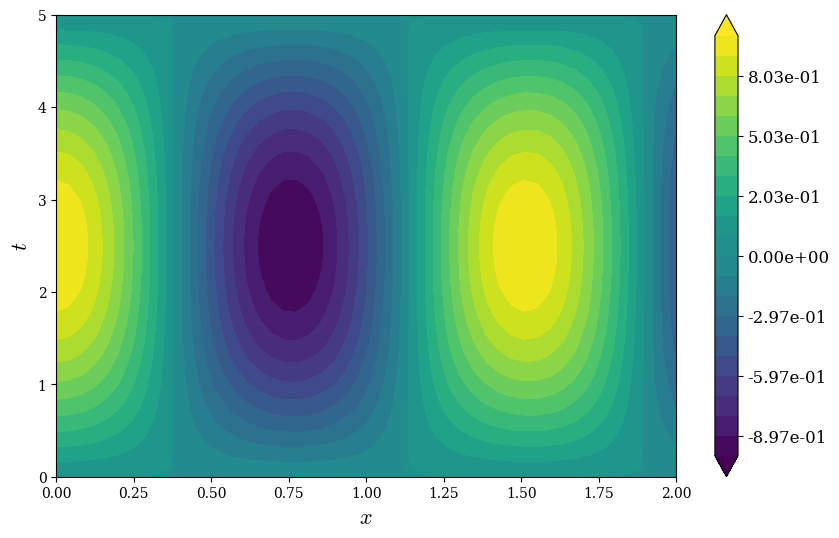

In [9]:
numerical.plot_solution_PDE(numerical_solution, mesh_x, mesh_t, surface=False)

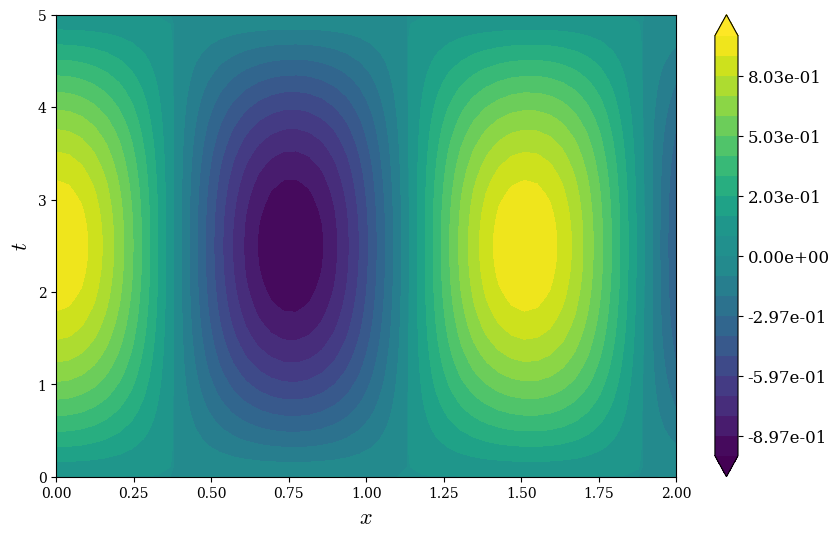

In [10]:
numerical.plot_solution_PDE(NN_TL_pertubation_solution, mesh_x, mesh_t, surface=False)

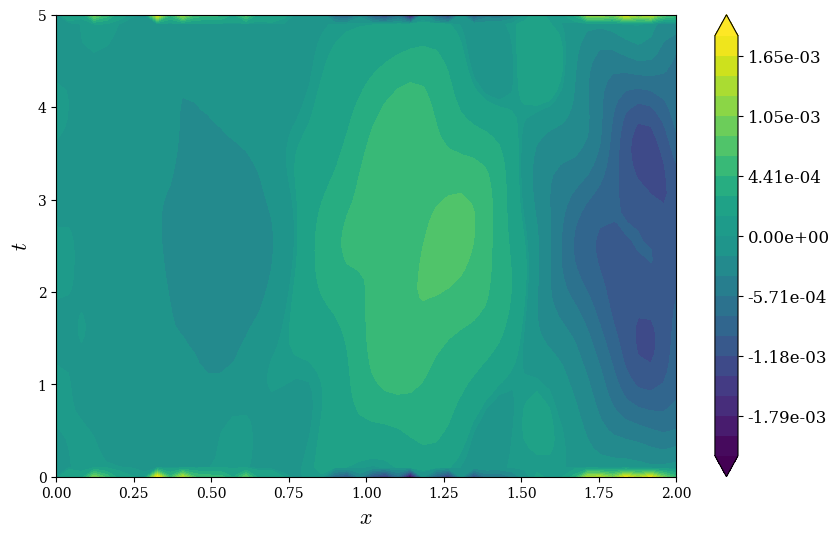

In [11]:
numerical.plot_solution_PDE(NN_TL_pertubation_solution - numerical_solution, mesh_x, mesh_t, surface=False)

In [12]:
np.mean(np.abs(NN_TL_pertubation_solution - numerical_solution))

np.float64(0.0002935579676488528)

In [13]:
numerical_solution_low_acc_RK45 = solution_wave(epsilons, c, polynomial, x_span, t_span, Nx, Nt, 
                        u0, v0, [lambda x, t: np.zeros_like(x)], [(left_bc, right_bc)], atol=1e-3, rtol=1e-3)[0]

numerical_solution_low_acc_Radau = solution_wave(epsilons, c, polynomial, x_span, t_span, Nx, Nt, 
                        u0, v0, [lambda x, t: np.zeros_like(x)], [(left_bc, right_bc)], atol=1e-3, rtol=1e-3, method="Radau")[0]

In [14]:
np.mean(np.abs(numerical_solution_low_acc_RK45 - numerical_solution))

np.float64(0.0010634634549259332)

In [15]:
np.mean(np.abs(numerical_solution_low_acc_Radau - numerical_solution))

np.float64(0.0005631544364756105)

## Hyperparameter sweep — MAE vs perturbation order

The nonlinear wave equation
\[
  u_{tt} \;=\; c^{2}\,u_{xx} \;-\; \varepsilon\,u^{3},
  \qquad u(x,0) = \sin(\pi x / L),\quad u_t(x,0)=0,\quad u(0,t)=u(L,t)=0
\]
is solved with the polynomial perturbation series on top of several
hyperparameter choices of the underlying `Multihead_model_PDE`
(`tanh` activations, hidden layout `[h_1, h_2, h_3]`):

- **Pretrained PINN** — `model_Wave_linear.pth`, architecture
  `[100, 100, 350]` (W=350).  This is the same model used in the rest of
  the notebook.
- **Random tanh PINNs** — untrained networks with widths
  `[W, W, 2W]` for `W ∈ {64, 128, 256}` (only the feature size
  changes; activation is the same `tanh`).

For each configuration we record the MAE of the cumulative
PTL-PINN solution $\sum_{k=0}^{p} \varepsilon^k u_k(x,t)$ against the
high-resolution Radau reference `numerical_solution`, for every
perturbation order $p = 0,\dots,p_{\max}$.

In [16]:
def _make_pretrained_pinn_wave():
    """Load the actual model used in the rest of the notebook."""
    m = model.Multihead_model_PDE(k=9, bias=True)
    m.load_state_dict(torch.load(f'{path}/{name}'))
    return m


def _make_random_pinn_wave(hidden_layers, seed=0):
    """Random `Multihead_model_PDE` with the requested hidden-layer sizes."""
    torch.manual_seed(seed)
    np.random.seed(seed)
    return model.Multihead_model_PDE(
        k=training_log['k'], bias=training_log['bias'],
        hidden_layers=hidden_layers,
    )


p_max = p   # use the same perturbation order as the main experiment (5)

# NOTE: each configuration requires autograd-differentiating H w.r.t. x and t
# once per feature column, so the runtime scales linearly with the last
# hidden dimension.  Widths above ~512 take several minutes per config; we
# stop at [256, 256, 512] which already saturates accuracy (see below).
sweep_configs = [
    ("Pretrained tanh PINN (actual model, [100,100,350])",
        _make_pretrained_pinn_wave),
    ("Random tanh PINN ([64,64,128])",
        lambda: _make_random_pinn_wave([64, 64, 128])),
    ("Random tanh PINN ([128,128,256])",
        lambda: _make_random_pinn_wave([128, 128, 256])),
    ("Random tanh PINN ([256,256,512])",
        lambda: _make_random_pinn_wave([256, 256, 512])),
]

# Re-build the problem data for the sweep helpers (matches the
# perturbation cell above).
ic_sweepD     = icD                          # Dirichlet IC (displacement)
ic_sweepN     = icN                          # Neumann IC   (velocity)
bcs_sweep     = [constant_function(0), constant_function(0)]
forcing_sweep = constant_function(0)
Polynomial_sweep = Polynomial                # [[1, 3]]  (i.e. +u^3)
input_interior   = torch.cat((x.unsqueeze(1), t.unsqueeze(1)), dim=1)

[label for label, _ in sweep_configs]

['Pretrained tanh PINN (actual model, [100,100,350])',
 'Random tanh PINN ([64,64,128])',
 'Random tanh PINN ([128,128,256])',
 'Random tanh PINN ([256,256,512])']

In [17]:
errors_by_label = {}

for label, factory in sweep_configs:
    pinn_cfg = factory()

    err, H_cfg = transfer_wave.compute_error_per_order_wave(
        model=pinn_cfg,
        IG=(Nx, Nt), Nic=Nx, Nbc=Nt, bias=False,
        x_span=x_span, t_span=t_span,
        training_log=training_log, c=c,
        p_max=p_max, epsilon=epsilon,
        forcing=forcing_sweep,
        Polynomial=Polynomial_sweep,
        ic_functionD=ic_sweepD,
        ic_functionN=ic_sweepN,
        boundary_functions=bcs_sweep,
        input_interior=input_interior,
        reference_solution=numerical_solution,
    )

    cond_H = np.linalg.cond(H_cfg['H'])

    legend_label = (
        f"{label}  [$\\kappa(H)$={cond_H:.1e}, "
        f"MAE@$p$={len(err) - 1}: {err[-1]:.2e}]"
    )
    errors_by_label[legend_label] = err
    print(f"{label:<55s}  MAE @ p={len(err) - 1}: {err[-1]:.3e}  |  cond(H)={cond_H:.2e}")

errors_by_label

Differentiating H w.r.t. x now...


Finished computing H2x.
Differentiating H w.r.t. t now...


Finished computing H2t
Differentiating H_ic w.r.t. t now...
Finished computing Ht_bc


Pretrained tanh PINN (actual model, [100,100,350])       MAE @ p=5: 2.936e-04  |  cond(H)=3.02e+09
Differentiating H w.r.t. x now...


Finished computing H2x.
Differentiating H w.r.t. t now...


...

Finished computing H2x.
Differentiating H w.r.t. t now...


Finished computing H2t
Differentiating H_ic w.r.t. t now...


Finished computing Ht_bc


Random tanh PINN ([256,256,512])                         MAE @ p=5: 6.040e-03  |  cond(H)=6.28e+16


{'Pretrained tanh PINN (actual model, [100,100,350])  [$\\kappa(H)$=3.0e+09, MAE@$p$=5: 2.94e-04]': [0.08948412288701887,
  0.01237794599530197,
  0.002160343342031714,
  0.00038340517430812004,
  0.00027400104525321416,
  0.0002935579676488528],
 'Random tanh PINN ([64,64,128])  [$\\kappa(H)$=3.6e+10, MAE@$p$=5: 6.34e-03]': [0.08912169300849744,
  0.012311110440825423,
  0.006195265581164412,
  0.006482910280449603,
  0.006308774244657162,
  0.006341943578723738],
 'Random tanh PINN ([128,128,256])  [$\\kappa(H)$=3.5e+14, MAE@$p$=5: 6.50e-03]': [0.08943152953382434,
  0.012252674773353381,
  0.006749076639579323,
  0.00673767824592306,
  0.006441772917458995,
  0.006503381494358966],
 'Random tanh PINN ([256,256,512])  [$\\kappa(H)$=6.3e+16, MAE@$p$=5: 6.04e-03]': [0.08951708464390042,
  0.012340646462412584,
  0.006375850062849326,
  0.006258955402200694,
  0.005984559316241608,
  0.0060404741391681975]}

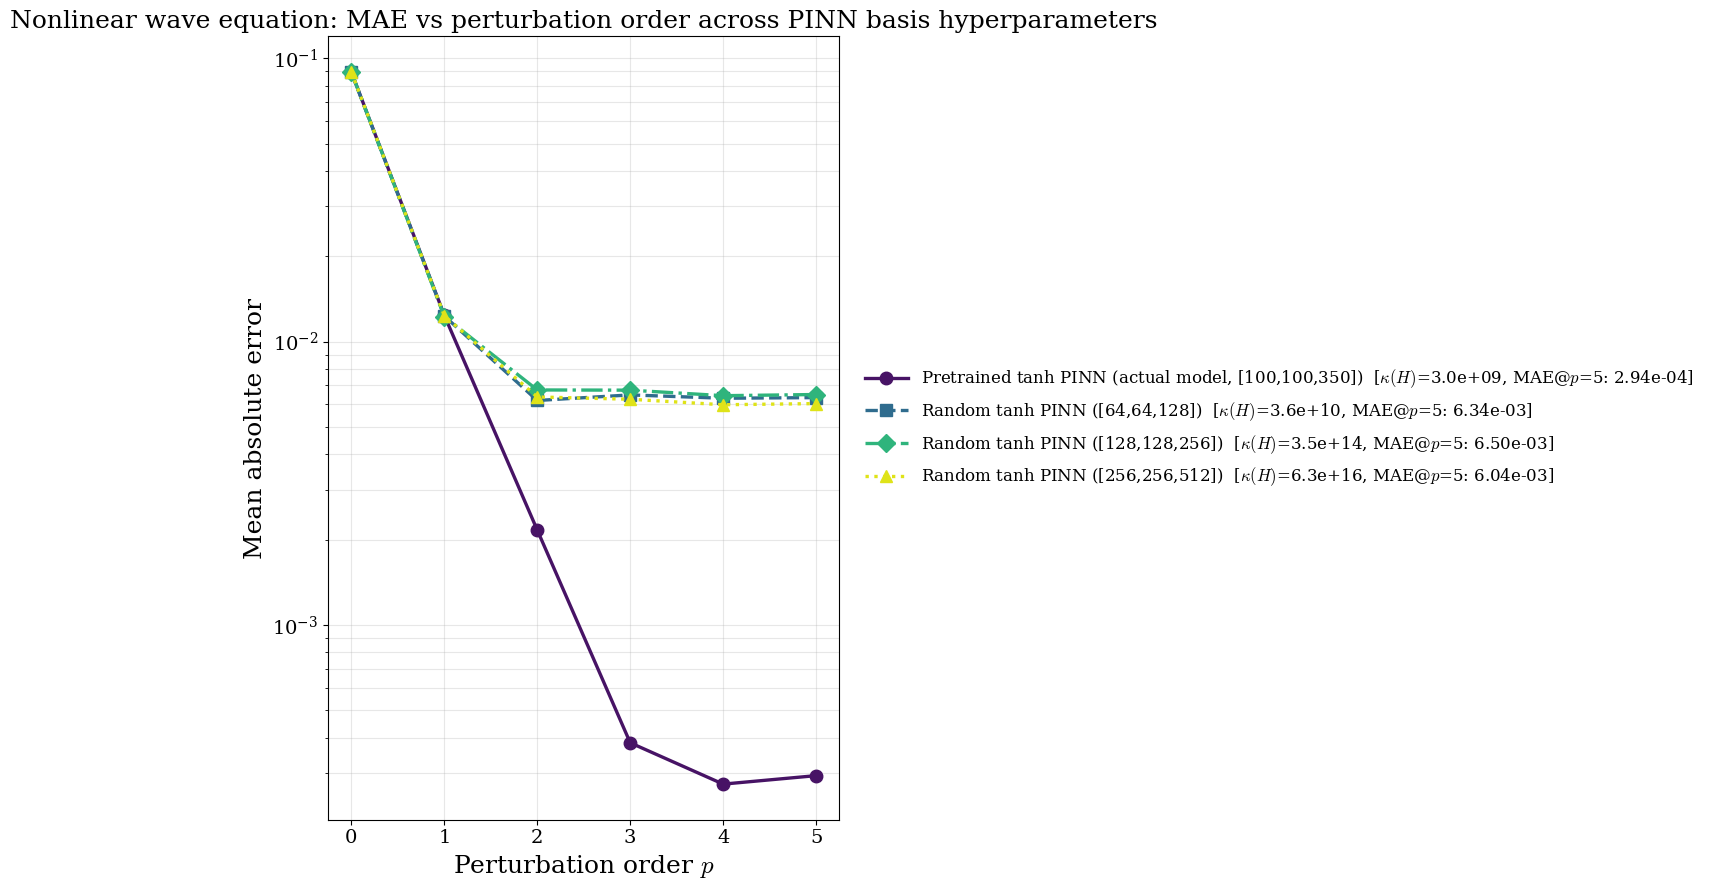

(<Figure size 1500x900 with 1 Axes>,
 <Axes: title={'center': 'Nonlinear wave equation: MAE vs perturbation order across PINN basis hyperparameters'}, xlabel='Perturbation order $p$', ylabel='Mean absolute error'>)

In [18]:
LKV.plot_mae_vs_order(
    errors_by_label,
    title="Nonlinear wave equation: MAE vs perturbation order across PINN basis hyperparameters",
)